# Day 25 - Customer Order Hypothesis Test

## 분석 목적

VIP 고객과 Non-VIP 고객의 평균 주문 수 차이를 비교하고,
관측된 차이가 표본 변동만으로 설명할 수 있는 수준인지
가설검정과 독립표본 t검정을 이용해 평가한다.

p-value만으로 결론을 내리지 않고
각 집단의 표본 수, 평균, 표준편차와 실제 평균 차이를 함께 확인한다.

## 분석 질문

1. VIP와 Non-VIP 고객의 평균 주문 수는 얼마나 다른가?
2. 이 평균 차이는 표본 변동만으로도 나타날 수 있는 수준인가?
3. p-value가 의미하는 것은 무엇인가?
4. 통계적으로 유의한 차이가 실제로 큰 차이를 의미하는가?
5. 현재 결과를 인과관계로 해석할 수 있는가?

## 가설

### 귀무가설 H0

VIP 고객과 Non-VIP 고객의 모집단 평균 주문 수는 같다.

### 대립가설 H1

VIP 고객과 Non-VIP 고객의 모집단 평균 주문 수는 다르다.

### 유의수준

alpha = 0.05

p-value가 alpha보다 작으면 귀무가설을 기각한다.

p-value가 alpha 이상이면
귀무가설을 기각하지 못한다.

귀무가설을 기각하지 못했다고
두 집단의 평균이 완전히 같다고 결론 내리지는 않는다.

In [14]:
# 라이브러리와 경로
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

project_root = Path.cwd().parent

input_path = (
    project_root
    / "outputs"
    / "customer_order_mini_project.csv"
)

output_dir = (
    project_root
    / "outputs"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print(input_path)
print(input_path.exists())

d:\Study\Projects\00_foundation_review\outputs\customer_order_mini_project.csv
True


In [15]:
# 데이터 불러오기
df = pd.read_csv(
    input_path
)

print(
    df.shape
)

print(
    df.head()
)

(30, 18)
   customer_id customer_name   region grade  total_order_count  \
0            1           Kim    Seoul   VIP                  9   
1            5           Han    Seoul   VIP                  8   
2            6          Jung    Busan  GOLD                  7   
3            9          Yoon  Daejeon   VIP                  6   
4           25           Bae  Incheon   VIP                  6   

   paid_order_count  cancelled_order_count  paid_rate first_order_date  \
0                 9                      0      100.0       2026-01-15   
1                 8                      0      100.0       2025-12-20   
2                 6                      1       85.7       2026-01-05   
3                 6                      0      100.0       2026-01-07   
4                 6                      0      100.0       2026-01-12   

  last_order_date data_reference_date  active_period_days  \
0      2026-07-30          2026-07-31               196.0   
1      2026-07-31          

In [16]:
# 필요한 열 확인
print(
    df[
        [
            "grade",
            "total_order_count"
        ]
    ].head()
)

print(
    df[
        [
            "grade",
            "total_order_count"
        ]
    ].isna().sum()
)

  grade  total_order_count
0   VIP                  9
1   VIP                  8
2  GOLD                  7
3   VIP                  6
4   VIP                  6
grade                0
total_order_count    0
dtype: int64


In [17]:
# 등급 분포 확인
print(
    df[
        "grade"
    ].value_counts()
)

grade
BASIC    12
GOLD     10
VIP       8
Name: count, dtype: int64


In [18]:
# 두 집단 만들기
vip_order_count = (
    df[
        df["grade"] == "VIP"
    ][
        "total_order_count"
    ].dropna()
)

non_vip_order_count = (
    df[
        df["grade"] != "VIP"
    ][
        "total_order_count"
    ].dropna()
)

print(
    "VIP 고객 수:",
    len(vip_order_count)
)

print(
    "Non-VIP 고객 수:",
    len(non_vip_order_count)
)

VIP 고객 수: 8
Non-VIP 고객 수: 22


## 기술통계 먼저 확인

가설검정을 실행하기 전에
두 그룹의 실제 데이터 차이를 먼저 확인한다.

p-value만 보고 분석하면
차이의 방향과 크기를 놓칠 수 있다.

따라서 각 그룹의

- 표본 수
- 평균
- 표준편차

를 먼저 확인한다.

In [19]:
vip_count = len(
    vip_order_count
)

non_vip_count = len(
    non_vip_order_count
)

vip_mean = (
    vip_order_count
    .mean()
)

non_vip_mean = (
    non_vip_order_count
    .mean()
)

vip_std = (
    vip_order_count
    .std()
)

non_vip_std = (
    non_vip_order_count
    .std()
)

mean_difference = (
    vip_mean
    - non_vip_mean
)

print(
    "VIP 고객 수:",
    vip_count
)

print(
    "VIP 평균 주문 수:",
    vip_mean
)

print(
    "VIP 표준편차:",
    vip_std
)

print(
    "Non-VIP 고객 수:",
    non_vip_count
)

print(
    "Non-VIP 평균 주문 수:",
    non_vip_mean
)

print(
    "Non-VIP 표준편차:",
    non_vip_std
)

print(
    "평균 차이:",
    mean_difference
)

VIP 고객 수: 8
VIP 평균 주문 수: 6.0
VIP 표준편차: 1.6903085094570331
Non-VIP 고객 수: 22
Non-VIP 평균 주문 수: 2.5454545454545454
Non-VIP 표준편차: 1.8702501163843026
평균 차이: 3.4545454545454546


In [20]:
# 그룹 요약표
group_summary_df = pd.DataFrame(
    {
        "group": [
            "VIP",
            "Non-VIP",
        ],
        "customer_count": [
            vip_count,
            non_vip_count,
        ],
        "mean_order_count": [
            vip_mean,
            non_vip_mean,
        ],
        "std_order_count": [
            vip_std,
            non_vip_std,
        ],
    }
)

print(
    group_summary_df
)

     group  customer_count  mean_order_count  std_order_count
0      VIP               8          6.000000         1.690309
1  Non-VIP              22          2.545455         1.870250


In [21]:
# 그룹 요약 저장
group_summary_output_path = (
    output_dir
    / "customer_grade_order_group_summary.csv"
)

group_summary_df.to_csv(
    group_summary_output_path,
    index=False
)

print(
    group_summary_output_path.exists()
)

True


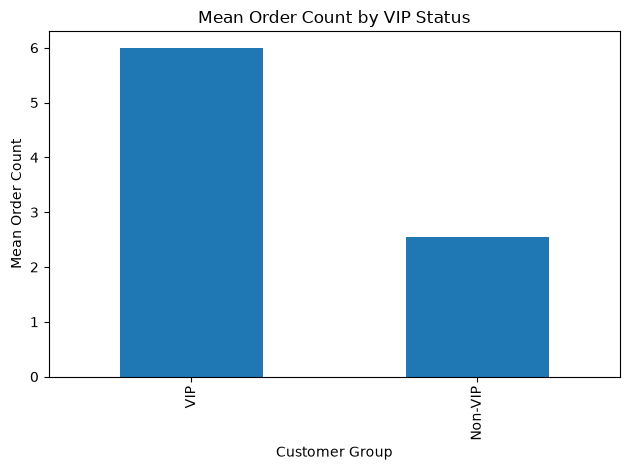

In [22]:
# 평균 주문 수 비교 그래프
figure_path = (
    output_dir
    / "customer_grade_order_mean_comparison.png"
)

group_summary_df.plot.bar(
    x="group",
    y="mean_order_count",
    legend=False
)

plt.title(
    "Mean Order Count by VIP Status"
)

plt.xlabel(
    "Customer Group"
)

plt.ylabel(
    "Mean Order Count"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Welch 독립표본 t검정

VIP와 Non-VIP는 서로 다른 고객 집단이므로
독립표본 t검정을 사용한다.

또한 두 집단의 표본 수와 분산이 같다고
확신할 근거가 없으므로 equal_var=False를 사용해
Welch t검정을 수행한다.

검정 결과에서 확인할 값은

- t-statistic
- p-value

이다.

In [23]:
# Welch t검정
test_result = ttest_ind(
    vip_order_count,
    non_vip_order_count,
    equal_var=False
)

t_statistic = (
    test_result.statistic
)

p_value = (
    test_result.pvalue
)

print(
    "t-statistic:",
    t_statistic
)

print(
    "p-value:",
    p_value
)

t-statistic: 4.808494199818816
p-value: 0.00029444473731175504


## t통계량의 부호

이번 코드에서는 VIP 그룹을 첫 번째,
Non-VIP 그룹을 두 번째로 넣었다.

따라서 t통계량이 양수라면
VIP 평균이 Non-VIP 평균보다 높은 방향이다.

음수라면 반대 방향이다.

다만 실제 차이의 크기는
각 그룹의 평균과 mean_difference를 직접 확인한다.

In [24]:
# 유의수준과 판단
alpha = 0.05

if p_value < alpha:
    test_decision = (
        "reject_null_hypothesis"
    )
else:
    test_decision = (
        "fail_to_reject_null_hypothesis"
    )

print(
    "유의수준:",
    alpha
)

print(
    "검정 판단:",
    test_decision
)

유의수준: 0.05
검정 판단: reject_null_hypothesis


## p-value < 0.05인 경우

- 유의수준 0.05에서 귀무가설을 기각한다.

현재 데이터에서는 VIP 고객과 Non-VIP 고객의

평균 주문 수가 같다고 보기 어려운 통계적 근거가 관측되었다.

## p-value >= 0.05인 경우

- 유의수준 0.05에서 귀무가설을 기각하지 못한다.

현재 데이터만으로는 VIP 고객과 Non-VIP 고객의

모집단 평균 주문 수가 다르다고 판단할 충분한

통계적 근거를 확보하지 못했다.

이는 두 집단의 평균이 완전히 같다는 의미는 아니다.

In [25]:
# 검정 결과 요약표
test_result_df = pd.DataFrame(
    {
        "metric": [
            "vip_count",
            "non_vip_count",
            "vip_mean",
            "non_vip_mean",
            "mean_difference",
            "t_statistic",
            "p_value",
            "alpha",
        ],
        "value": [
            vip_count,
            non_vip_count,
            vip_mean,
            non_vip_mean,
            mean_difference,
            t_statistic,
            p_value,
            alpha,
        ],
    }
)

print(
    test_result_df
)

            metric      value
0        vip_count   8.000000
1    non_vip_count  22.000000
2         vip_mean   6.000000
3     non_vip_mean   2.545455
4  mean_difference   3.454545
5      t_statistic   4.808494
6          p_value   0.000294
7            alpha   0.050000


In [26]:
# 결과 저장
test_result_output_path = (
    output_dir
    / "customer_grade_order_ttest_result.csv"
)

test_result_df.to_csv(
    test_result_output_path,
    index=False
)

print(
    test_result_output_path.exists()
)

True


## 통계적 유의성과 실제 차이

p-value가 작다는 것은
현재 결과가 귀무가설과 잘 맞지 않는다는 의미다.

그러나 p-value가 작다고
VIP와 Non-VIP의 평균 차이가 반드시 크거나
업무적으로 중요하다는 의미는 아니다.

따라서 다음을 함께 본다.

- 각 그룹의 표본 수
- 각 그룹의 평균
- 각 그룹의 표준편차
- 실제 평균 차이
- p-value

p-value 하나만으로 결론을 내리지 않는다.

## 분석 한계

현재 분석 데이터는 Day 20에서 학습 목적으로 만든
30명의 가상 고객 데이터다.

실제 모집단에서 무작위 추출된 표본이 아니므로
검정 결과를 실제 시장 전체 고객에게 일반화할 수 없다.

또한 고객 등급의 부여 기준과 주문 행동의 시간적 선후 관계를
현재 데이터만으로 확인할 수 없다.

따라서 평균 차이가 통계적으로 유의하게 나타나더라도
VIP 등급이 주문 증가의 원인이라고 해석하지 않는다.

이번 분석의 목적은 가설검정, p-value와
독립표본 t검정의 판단 구조를 이해하는 것이다.

## 핵심 결과

### 1. 그룹별 평균

VIP 고객 수: 8

VIP 평균 주문 수: 6

Non-VIP 고객 수: 22

Non-VIP 평균 주문 수: 2.5

평균 차이: 3.5


### 2. 가설검정

귀무가설:

VIP와 Non-VIP 고객의 모집단 평균 주문 수는 같다.

대립가설:

VIP와 Non-VIP 고객의 모집단 평균 주문 수는 다르다.

t-statistic: 4.8

p-value: 0.0002

유의수준:
0.05

판단: 귀무가설 기각


### 3. 결과 해석

유의수준 0.05에서 귀무가설을 기각한다.


### 4. 업무 해석

통계적 유의성만으로 고객 관리 전략을 결정하지 않는다.

실제 평균 차이와 고객 수,
등급 정의와 고객 관리 목적을 함께 검토해야 한다.


### 5. 분석 한계

현재 데이터는 학습용 가상 데이터이며
실제 모집단에서 무작위 추출된 표본이 아니다.

또한 관찰 데이터이므로
VIP 등급과 주문 수 사이의 인과관계를 판단할 수 없다.